## Table of Contents

| Phase | Description | Key Output |
|:------|:------------|:-----------|
| **Phase 0** | Business framing & cost analysis | Cost matrix, metric choice |
| **Phase 1** | EDA & data understanding | Feature separation, anomaly detection |
| **Phase 2** | Multi-table aggregation (7 tables) | 500+ aggregated features |
| **Phase 3** | Feature engineering & leakage-free pipeline | Ratio features, Pipeline |
| **Phase 4** | Modeling: LR → DT → RF → LightGBM → CatBoost → Ensemble | PR-AUC comparison |
| **Phase 5** | Hyperparameter tuning (Optuna) + threshold selection | Cost-optimal threshold |
| **Phase 6** | Evaluation: metrics, SHAP, error analysis, calibration | Explainability |
| **Phase 7** | Business impact analysis | Financial savings ($) |

---
## Phase 0 — Business Problem First

 **Rule:** Define what "success" means in *business terms* before touching a single line of code.
>
### What is Home Credit trying to do?
Home Credit gives loans to people with little or no formal credit history — people banks usually reject. The model must be careful but not paranoid:
- **Too cautious** → reject too many creditworthy people → lost revenue
- **Too lenient** → approve people who default → financial loss

### The Two Errors and Their Real Cost

| Error | What happens | Financial impact |
|:------|:-------------|:-----------------|
| **False Negative** (missed defaulter) | We approve a loan → client doesn't repay | Bank loses **~40%** of loan (Loss Given Default) |
| **False Positive** (rejected safe client) | We reject → client would have repaid | Bank loses **~17.5%** of potential interest (3.5% × 5 yrs) |
| **Ratio** | FN is **~6–10× more expensive** than FP | → Model should lean toward higher Recall |

### Why NOT Accuracy?

```
A naive model that predicts "no default" for EVERYONE:
  → Accuracy = 92%   ✓ (looks great!)
  → Defaulters caught = 0%  ✗ (completely useless)
```

### Chosen Metrics

| Metric | Reason |
|:-------|:-------|
| **PR-AUC** (primary) | Best for imbalanced data — summarizes full precision-recall tradeoff |
| **Recall ≥ 0.75** | Business floor — must catch ≥75% of real defaulters |
| **ROC-AUC** | Secondary reference only |
| ~~Accuracy~~ | Misleading — excluded as primary metric |

##  Setup & Imports

---
## Phase 1 — Data Understanding & EDA

 **Goal:** Understand the data shape, class distribution, missing values, and which features separate defaulters from non-defaulters — before touching any model.

 **Hypothesis:** ~8% default rate; EXT_SOURCE_ columns will be the strongest predictors.

### 1.1 — Load data

In [4]:
train = pd.read_csv('../home-credit-default-risk/application_train.csv')
test  = pd.read_csv('../home-credit-default-risk/application_test.csv')

print(f'Train : {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:,} rows × {test.shape[1]} cols')
train.head(3)

Train : 307,511 rows × 122 cols
Test  : 48,744 rows × 121 cols


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### 1.2 — Target distribution

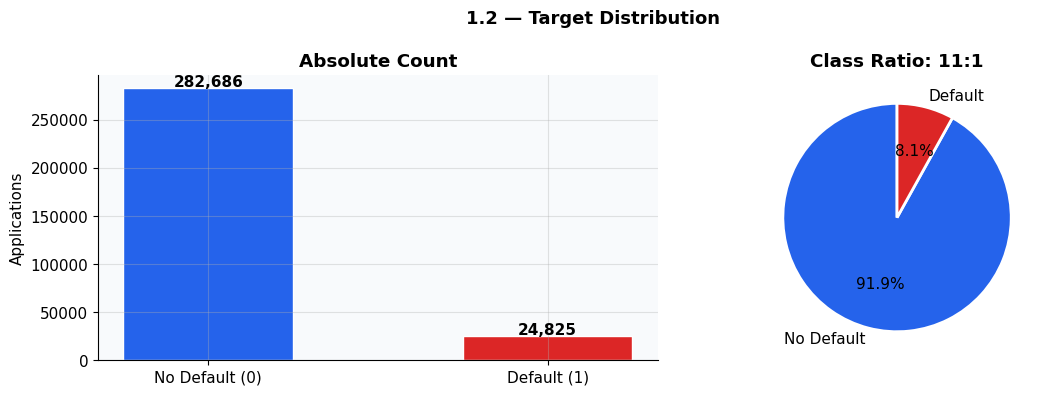

Default rate  = 8.1%
Class ratio   = 11.4:1

 KEY: 12:1 imbalance → Accuracy is misleading → use PR-AUC
   scale_pos_weight = 11.4 will compensate in LightGBM


In [5]:
default_rate = train['TARGET'].mean()
class_ratio  = (train['TARGET']==0).sum() / (train['TARGET']==1).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.2 — Target Distribution', fontsize=13, fontweight='bold')

counts = train['TARGET'].value_counts()
bars = axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
                   color=['#2563eb', '#dc2626'], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_ylabel('Applications')
axes[0].set_title('Absolute Count', fontweight='bold')

axes[1].pie([1-default_rate, default_rate],
            labels=['No Default', 'Default'],
            colors=['#2563eb', '#dc2626'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Class Ratio: {class_ratio:.0f}:1', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Default rate  = {default_rate*100:.1f}%')
print(f'Class ratio   = {class_ratio:.1f}:1')
print()
print(' KEY: 12:1 imbalance → Accuracy is misleading → use PR-AUC')
print('   scale_pos_weight = {:.1f} will compensate in LightGBM'.format(class_ratio))
SCALE_POS_WEIGHT = class_ratio

### 1.3 — Missing values analysis

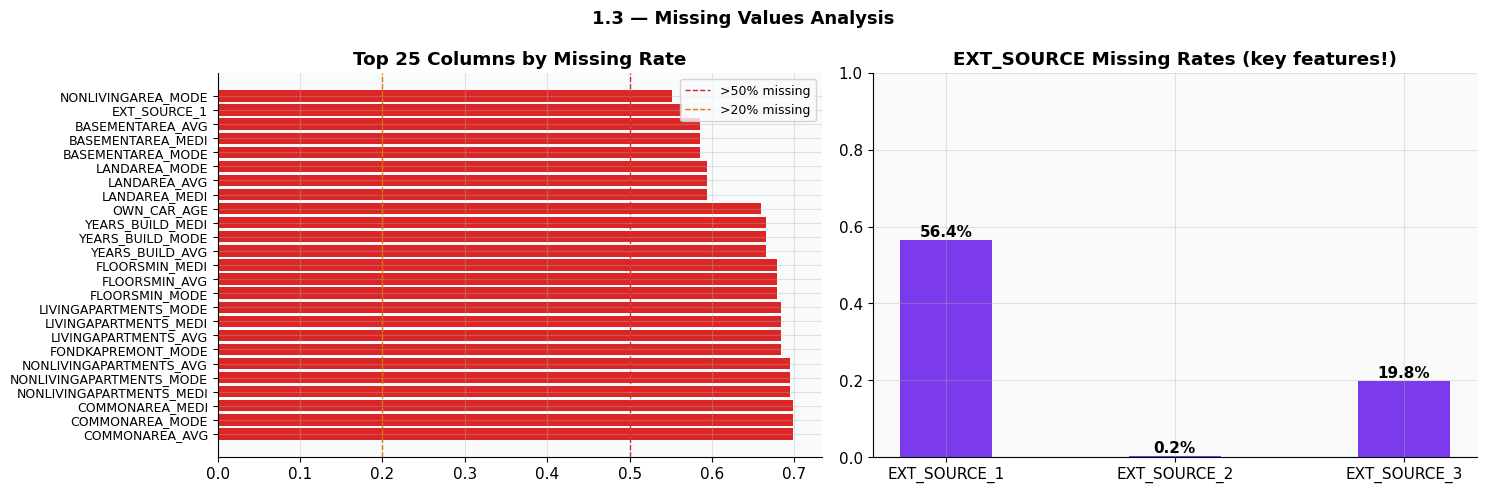

Columns with >50% missing : 41
📌 Decision: Impute INSIDE Pipeline (after split) — prevents data leakage


In [6]:
missing     = train.isnull().mean().sort_values(ascending=False)
missing_top = missing[missing > 0].head(25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('1.3 — Missing Values Analysis', fontsize=13, fontweight='bold')

colors = ['#dc2626' if v > 0.5 else '#d97706' if v > 0.2 else '#2563eb'
          for v in missing_top.values]
axes[0].barh(range(len(missing_top)), missing_top.values, color=colors)
axes[0].set_yticks(range(len(missing_top)))
axes[0].set_yticklabels(missing_top.index, fontsize=9)
axes[0].axvline(0.5, color='#dc2626', linestyle='--', linewidth=1, label='>50% missing')
axes[0].axvline(0.2, color='#d97706', linestyle='--', linewidth=1, label='>20% missing')
axes[0].set_title('Top 25 Columns by Missing Rate', fontweight='bold')
axes[0].legend(fontsize=9)

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_miss = [train[c].isnull().mean() for c in ext_cols]
axes[1].bar(ext_cols, ext_miss, color='#7c3aed', width=0.4)
for i, (col, val) in enumerate(zip(ext_cols, ext_miss)):
    axes[1].text(i, val+0.01, f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('EXT_SOURCE Missing Rates (key features!)', fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f'Columns with >50% missing : {(missing > 0.5).sum()}')
print('📌 Decision: Impute INSIDE Pipeline (after split) — prevents data leakage')

### 1.4 — Feature distributions vs Target (KS-test)

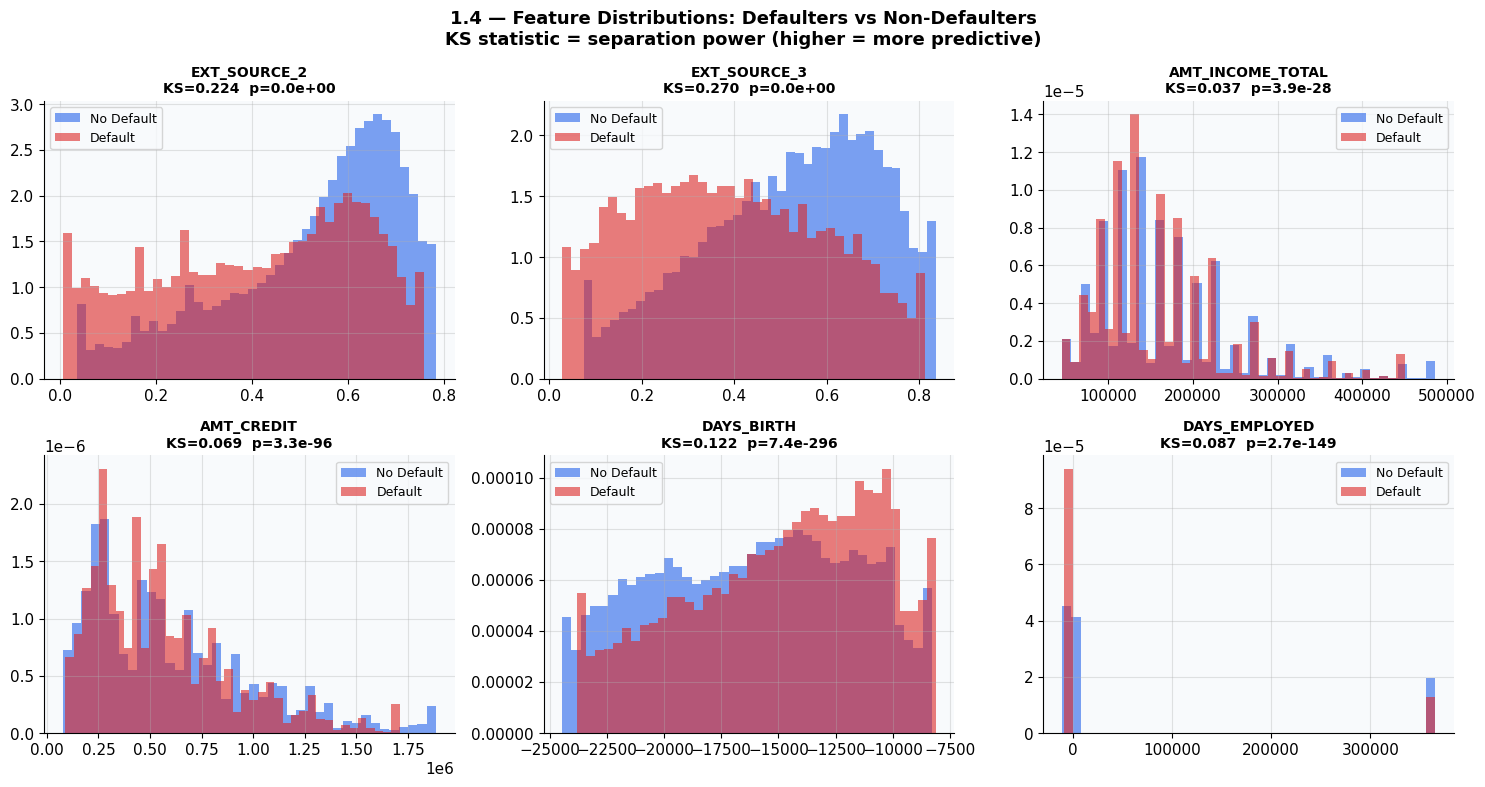

Feature separation power (KS statistic):
  EXT_SOURCE_3              KS=0.270  ********
  EXT_SOURCE_2              KS=0.224  ******
  DAYS_BIRTH                KS=0.122  ***
  DAYS_EMPLOYED             KS=0.087  **
  AMT_CREDIT                KS=0.069  **
  AMT_INCOME_TOTAL          KS=0.037  *

📌 EXT_SOURCE_2 and EXT_SOURCE_3 are strongest predictors
   DAYS_EMPLOYED has anomalous value 365243 → will fix in Phase 3


In [7]:
# KS statistic = how well the feature separates defaulters from non-defaulters
key_features = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL',
                'AMT_CREDIT', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('1.4 — Feature Distributions: Defaulters vs Non-Defaulters\n'
             'KS statistic = separation power (higher = more predictive)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

ks_results = {}
for i, feat in enumerate(key_features):
    for tval, color, label in [(0, '#2563eb', 'No Default'), (1, '#dc2626', 'Default')]:
        data = train.loc[train['TARGET']==tval, feat].dropna()
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        axes[i].hist(data.clip(p1, p99), bins=40, alpha=0.6,
                     color=color, label=label, density=True)
    ks_stat, ks_p = ks_2samp(
        train.loc[train['TARGET']==0, feat].dropna(),
        train.loc[train['TARGET']==1, feat].dropna()
    )
    ks_results[feat] = ks_stat
    axes[i].set_title(f'{feat}\nKS={ks_stat:.3f}  p={ks_p:.1e}', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Feature separation power (KS statistic):')
for feat, ks in sorted(ks_results.items(), key=lambda x: -x[1]):
    bar = '*' * int(ks * 30)
    print(f'  {feat:<25} KS={ks:.3f}  {bar}')
print()
print('📌 EXT_SOURCE_2 and EXT_SOURCE_3 are strongest predictors')
print('   DAYS_EMPLOYED has anomalous value 365243 → will fix in Phase 3')

### 1.5 — DAYS_EMPLOYED anomaly

Anomalous value (365243): 55,374 rows (18.0%)



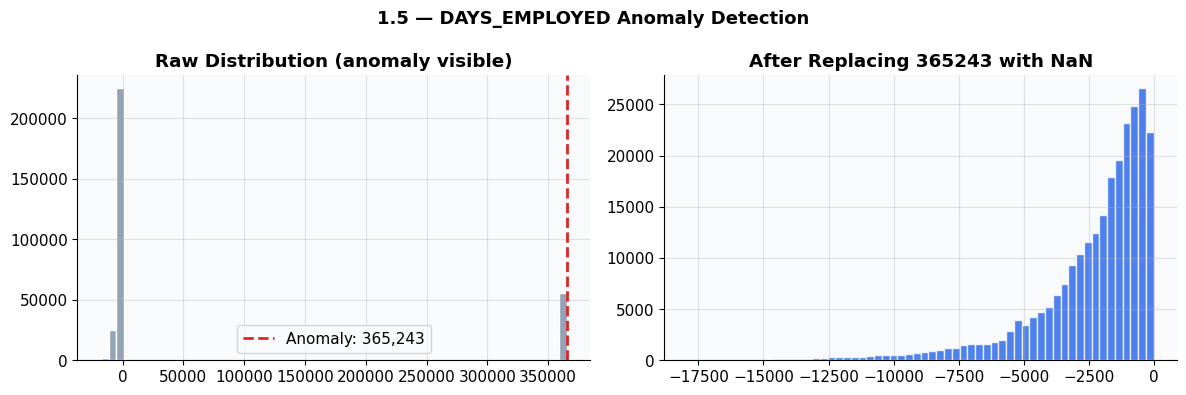

Decision: Replace 365243 with NaN + create DAYS_EMPLOYED_ANOM flag
   Pipeline will then impute with median safely


In [8]:
# Home Credit codes pensioners/unemployed as 365243 in DAYS_EMPLOYED
anomaly_count = (train['DAYS_EMPLOYED'] == 365243).sum()
print(f'Anomalous value (365243): {anomaly_count:,} rows ({anomaly_count/len(train)*100:.1f}%)')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.5 — DAYS_EMPLOYED Anomaly Detection', fontsize=13, fontweight='bold')

axes[0].hist(train['DAYS_EMPLOYED'], bins=60, color='#94a3b8', edgecolor='white')
axes[0].axvline(365243, color='#dc2626', lw=2, linestyle='--', label='Anomaly: 365,243')
axes[0].set_title('Raw Distribution (anomaly visible)', fontweight='bold')
axes[0].legend()

cleaned = train['DAYS_EMPLOYED'].replace(365243, np.nan)
axes[1].hist(cleaned.dropna(), bins=60, color='#2563eb', edgecolor='white', alpha=0.8)
axes[1].set_title('After Replacing 365243 with NaN', fontweight='bold')

plt.tight_layout()
plt.show()

print('Decision: Replace 365243 with NaN + create DAYS_EMPLOYED_ANOM flag')
print('   Pipeline will then impute with median safely')

---
## Phase 2 — Multi-Table Aggregation (All 7 Tables)

**Why aggregate instead of flatten?**
 Each client has *multiple* rows in sub-tables (many loans, many payments).
Flattening creates duplicates and leakage. Aggregation condenses history to one row per client.

| Table | Join Key | Records | Strategy |
|:------|:---------|:--------|:---------|
| bureau.csv | SK_ID_CURR | ~1.7M | agg(mean/max/min/sum/std) |
| bureau_balance.csv | SK_ID_BUREAU → SK_ID_CURR | ~27M | 2-step aggregation |
| installments_payments.csv | SK_ID_CURR | ~13M | agg + payment delay features |
| previous_application.csv | SK_ID_CURR | ~1.7M | agg + refusal rate |
| POS_CASH_balance.csv | SK_ID_CURR | ~10M | agg |
| credit_card_balance.csv | SK_ID_CURR | ~3.8M | agg |

 All joins are LEFT joins — clients with no history get NaN → handled inside Pipeline.

In [11]:
AGG_FUNCS = ['mean', 'max', 'min', 'sum', 'std']

def aggregate_table(df, group_key, prefix, agg_funcs=AGG_FUNCS, exclude_cols=None):
    """Aggregate a sub-table to one row per client with named features."""
    exclude_cols = exclude_cols or []
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                if c not in exclude_cols and c != group_key]
    
    agg_df = df.groupby(group_key)[num_cols].agg(agg_funcs).reset_index()
    agg_df.columns = [
        group_key if col[0] == group_key 
        else f'{prefix}_{col[0]}_{col[1]}' 
        for col in agg_df.columns
    ]
    
    print(f'  {prefix:<22} {df.shape[0]:>9,} rows → {len(agg_df):>7,} clients | {agg_df.shape[1]-1} features')
    return agg_df
def safe_merge(left_df, right_df, on_key='SK_ID_CURR'):
    """Merge two DataFrames safely regardless of index/column key location."""
    if on_key in right_df.columns:
        return left_df.merge(right_df, on=on_key, how='left')
    elif right_df.index.name == on_key:
        return left_df.merge(right_df, left_on=on_key, right_index=True, how='left')
    else:
        possible = [c for c in right_df.columns if on_key in str(c)]
        if possible:
            return left_df.merge(right_df, left_on=on_key, right_on=possible[0], how='left')
        raise KeyError(f"Key '{on_key}' not found in right DataFrame")



In [ ]:
# Load all sub-tables
bureau         = pd.read_csv('../home-credit-default-risk/bureau.csv')
bureau_balance = pd.read_csv('../home-credit-default-risk/bureau_balance.csv')
inst           = pd.read_csv('../home-credit-default-risk/installments_payments.csv')
prev           = pd.read_csv('../home-credit-default-risk/previous_application.csv')
pos_cash       = pd.read_csv('../home-credit-default-risk/POS_CASH_balance.csv')
credit_card    = pd.read_csv('../home-credit-default-risk/credit_card_balance.csv')

#Bureau (2-step: balance → bureau → main)                                  
# Critical: bureau_balance joins to bureau on SK_ID_BUREAU, NOT SK_ID_CURR
status_map = {'C':0,'X':0,'0':0,'1':1,'2':2,'3':3,'4':4,'5':5}
bureau_balance['STATUS_ENC'] = bureau_balance['STATUS'].map(status_map).fillna(0)
bb_agg = aggregate_table(bureau_balance, 'SK_ID_BUREAU', 'BB', exclude_cols=['STATUS'])
bureau_merged = safe_merge(bureau, bb_agg, on_key='SK_ID_BUREAU')
bureau_agg = aggregate_table(bureau_merged, 'SK_ID_CURR', 'BUREAU', exclude_cols=['SK_ID_BUREAU'])

# Add derived bureau features
grp = bureau.groupby('SK_ID_CURR')
bureau_agg['BUREAU_ACTIVE_RATIO'] = (
    (bureau['CREDIT_ACTIVE'] == 'Active').groupby(bureau['SK_ID_CURR']).mean()
).reindex(bureau_agg['SK_ID_CURR']).values
bureau_agg['BUREAU_OVERDUE_RATIO'] = (
    (bureau['CREDIT_DAY_OVERDUE'] > 0).groupby(bureau['SK_ID_CURR']).mean()
).reindex(bureau_agg['SK_ID_CURR']).values

print()

#Installments                                                               
inst['PAYMENT_DELAY']    = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['PAYMENT_RATIO']    = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1e-6)
inst['PAYMENT_SHORTAGE'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']
inst_agg = aggregate_table(inst, 'SK_ID_CURR', 'INST', exclude_cols=['SK_ID_PREV'])

print()

#Previous applications                                                      
prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / (prev['AMT_CREDIT'] + 1e-6)
prev_refused = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused']
prev_agg = aggregate_table(prev, 'SK_ID_CURR', 'PREV', exclude_cols=['SK_ID_PREV'])
prev_agg['PREV_REFUSAL_RATE'] = (
    prev_refused.groupby('SK_ID_CURR').size() / prev.groupby('SK_ID_CURR').size()
).reindex(prev_agg['SK_ID_CURR']).fillna(0).values

print()

#POS CASH balance                                                           
pos_cash['POS_DPD_FLAG'] = (pos_cash['SK_DPD'] > 0).astype(int)
pos_agg = aggregate_table(pos_cash, 'SK_ID_CURR', 'POS', exclude_cols=['SK_ID_PREV'])

print()

#    Credit card balance                                                        
credit_card['CC_UTIL_RATIO'] = (
    credit_card['AMT_BALANCE'] / (credit_card['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-6)
)
cc_agg = aggregate_table(credit_card, 'SK_ID_CURR', 'CC', exclude_cols=['SK_ID_PREV'])


  BB                     27,299,925 rows → 817,395 clients | 10 features
  BUREAU                 1,716,428 rows → 305,811 clients | 110 features

  INST                   13,605,401 rows → 339,587 clients | 45 features

  PREV                   1,670,214 rows → 338,857 clients | 100 features

  POS                    10,001,358 rows → 337,252 clients | 30 features

  CC                     3,840,312 rows → 103,558 clients | 105 features

✅ All 6 sub-tables aggregated


In [13]:
# Merge everything into main table
def build_features(df):
    """Merge all aggregated sub-tables onto the main application table."""
    out = df.copy()
    for agg_df in [bureau_agg, inst_agg, prev_agg, pos_agg, cc_agg]:
        out = safe_merge(out, agg_df)
    print(f'Final shape: {out.shape[0]:,} rows × {out.shape[1]} cols')
    return out

train_raw = build_features(train)
test_raw  = build_features(test)

Final shape: 307,511 rows × 515 cols
Final shape: 48,744 rows × 514 cols


---
## Phase 3 — Feature Engineering & Leakage-Free Pipeline

**Hypothesis:** Financial *ratios* are more informative than raw amounts.
 A $50k loan means very different risk for someone earning $20k vs $200k.

 **Critical rule:** ALL imputation and scaling happens **INSIDE** the Pipeline, **after** train/val split.
 Fitting on the full dataset before splitting leaks validation statistics into training — inflates scores artificially.

In [14]:
def engineer_features(df):
    """Add domain-specific ratio features and fix known anomalies."""
    df = df.copy()
    eps = 1e-6

    #    Fix known anomaly                                                       
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    #    Financial ratios                                                        
    df['FEAT_CREDIT_TO_INCOME']  = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + eps)
    df['FEAT_ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + eps)
    df['FEAT_CREDIT_TO_GOODS']   = df['AMT_CREDIT']  / (df['AMT_GOODS_PRICE']  + eps)
    df['FEAT_DEBT_TO_INCOME']    = (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE'].fillna(0))/ (df['AMT_INCOME_TOTAL'] + eps)

    #    Age & employment                                                        
    df['FEAT_AGE_YEARS']      = (-df['DAYS_BIRTH'])    / 365
    df['FEAT_EMPLOY_YEARS']   = (-df['DAYS_EMPLOYED']) / 365
    df['FEAT_EMPLOY_TO_AGE']  = df['FEAT_EMPLOY_YEARS'] / (df['FEAT_AGE_YEARS'] + eps)

    #    EXT_SOURCE aggregation (strongest signal)                               
    ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
    df['FEAT_EXT_MEAN'] = df[ext_cols].mean(axis=1)
    df['FEAT_EXT_MIN']  = df[ext_cols].min(axis=1)
    df['FEAT_EXT_MAX']  = df[ext_cols].max(axis=1)
    df['FEAT_EXT_STD']  = df[ext_cols].std(axis=1)

    #   Documents (how many docs submitted)                                    
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if doc_cols:
        df['FEAT_DOCS_SUBMITTED'] = df[doc_cols].sum(axis=1)

    return df

train_fe = engineer_features(train_raw)
test_fe  = engineer_features(test_raw)

feat_cols = [c for c in train_fe.columns if c.startswith('FEAT_')]
print(f'Engineered features added: {len(feat_cols)}')
for f in feat_cols:
    print(f'  {f}')

Engineered features added: 12
  FEAT_CREDIT_TO_INCOME
  FEAT_ANNUITY_TO_INCOME
  FEAT_CREDIT_TO_GOODS
  FEAT_DEBT_TO_INCOME
  FEAT_AGE_YEARS
  FEAT_EMPLOY_YEARS
  FEAT_EMPLOY_TO_AGE
  FEAT_EXT_MEAN
  FEAT_EXT_MIN
  FEAT_EXT_MAX
  FEAT_EXT_STD
  FEAT_DOCS_SUBMITTED


In [15]:
#  Train / Validation split (stratified to preserve class ratio) 
X = train_fe.drop(columns=['TARGET', 'SK_ID_CURR'])
y = train_fe['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]:,} rows | Val : {X_val.shape[0]:,} rows')
print(f'Default rate — Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f}')
print()

# Build leakage-free preprocessing pipeline 
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
], remainder='drop')

# Fit ONLY on training data — validation data is never seen during fitting
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'✅ Pipeline fitted — X_train_proc: {X_train_proc.shape}')
print(f'   scale_pos_weight = {scale_pos_weight:.1f} (compensates for class imbalance in LightGBM)')

Train : 246,008 rows | Val : 61,503 rows
Default rate — Train: 0.081 | Val: 0.081

✅ Pipeline fitted — X_train_proc: (246008, 526)
   scale_pos_weight = 11.4 (compensates for class imbalance in LightGBM)


---
## Phase 4 — Modeling: Simple → Complex

 **Strategy:** Start simple, add complexity only when it delivers measurable PR-AUC improvement.



3.1  Logistic Regression    → establishes the floor (what any model must beat)
3.2  Decision Tree          → shows bias-variance tradeoff
3.3  Random Forest          → wisdom of crowds, parallel trees
3.4  LightGBM + CatBoost   → sequential boosting, best for tabular data
3.5  Ensemble               → weighted combination of best models


In [16]:
# Helper  evaluate any model consistently
def evaluate_model(name, proba, y_true=y_val, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    pr_auc  = average_precision_score(y_true, proba)
    roc_auc = roc_auc_score(y_true, proba)
    prec    = precision_score(y_true, pred, zero_division=0)
    rec     = recall_score(y_true, pred)
    f1      = f1_score(y_true, pred, zero_division=0)
    print(f'  {name:<28} PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  '
          f'Prec={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}')
    return {'Model': name, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
            'Precision': prec, 'Recall': rec, 'F1': f1}

all_results = []
print('Model evaluations (threshold=0.5):')
print()

Model evaluations (threshold=0.5):



In [17]:
#  4.1 Baseline: Logistic Regression 
lr = LogisticRegression(C=0.01, class_weight='balanced',
                         solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_proc, y_train)
lr_proba = lr.predict_proba(X_val_proc)[:, 1]
all_results.append(evaluate_model('Logistic Regression', lr_proba))
baseline_pr_auc = all_results[0]['PR-AUC']
print()
print(f'📌 Baseline floor: PR-AUC = {baseline_pr_auc:.4f} — every model must beat this')

  Logistic Regression          PR-AUC=0.2604  ROC-AUC=0.7727  Prec=0.174  Recall=0.698  F1=0.278

📌 Baseline floor: PR-AUC = 0.2604 — every model must beat this


In [18]:
#    4.2 Decision Tree — learning about overfitting                             
# First: unlimited depth → overfit
dt_overfit = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_overfit.fit(X_train_proc, y_train)
train_score = average_precision_score(y_train, dt_overfit.predict_proba(X_train_proc)[:,1])
val_score   = average_precision_score(y_val,   dt_overfit.predict_proba(X_val_proc)[:,1])
print(f'Unlimited depth → Train PR-AUC={train_score:.4f} | Val PR-AUC={val_score:.4f}')
print(f'Overfit gap = {train_score-val_score:.4f} ← clearly overfitting')
print()

# Regularized: max_depth=8
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                              class_weight='balanced', random_state=42)
dt.fit(X_train_proc, y_train)
dt_proba = dt.predict_proba(X_val_proc)[:, 1]
all_results.append(evaluate_model('Decision Tree (depth=8)', dt_proba))

Unlimited depth → Train PR-AUC=1.0000 | Val PR-AUC=0.0944
Overfit gap = 0.9056 ← clearly overfitting

  Decision Tree (depth=8)      PR-AUC=0.2015  ROC-AUC=0.7208  Prec=0.148  Recall=0.671  F1=0.242


In [19]:
#    4.3 Random Forest                                                         
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=30,
                              class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_proc, y_train)
rf_proba = rf.predict_proba(X_val_proc)[:, 1]
all_results.append(evaluate_model('Random Forest (200 trees)', rf_proba))
print()
print('📌 RF improves over DT by combining 200 diverse trees (wisdom of crowds)')
print('   But each tree trains independently — they don\'t learn from each other\'s mistakes')

  Random Forest (200 trees)    PR-AUC=0.2437  ROC-AUC=0.7629  Prec=0.201  Recall=0.560  F1=0.296

📌 RF improves over DT by combining 200 diverse trees (wisdom of crowds)
   But each tree trains independently — they don't learn from each other's mistakes


In [20]:
#    4.4 LightGBM                                                              
# Why boosting beats RF on tabular data:
# Trees train SEQUENTIALLY, each correcting the previous one's errors.
# Targeted correction → consistently wins on structured data.

lgbm = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1, random_state=42, verbose=-1
)
lgbm.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    callbacks=[early_stopping(50, verbose=False), log_evaluation(0)]
)
lgbm_proba = lgbm.predict_proba(X_val_proc)[:, 1]
r = evaluate_model('LightGBM (default)', lgbm_proba)
all_results.append(r)
print(f'   Improvement vs LR baseline: +{r["PR-AUC"] - baseline_pr_auc:.4f}')

  LightGBM (default)           PR-AUC=0.1957  ROC-AUC=0.7269  Prec=0.000  Recall=0.000  F1=0.000
   Improvement vs LR baseline: +-0.0647


In [21]:
#    4.5 CatBoost                                                              
catboost = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric='AUC', early_stopping_rounds=50,
    random_seed=42, verbose=0
)
catboost.fit(X_train_proc, y_train, eval_set=(X_val_proc, y_val))
cb_proba = catboost.predict_proba(X_val_proc)[:, 1]
all_results.append(evaluate_model('CatBoost', cb_proba))

  CatBoost                     PR-AUC=0.2881  ROC-AUC=0.7865  Prec=0.582  Recall=0.043  F1=0.080


In [22]:
#   4.6 Ensemble                                                              
# Combine LightGBM (60%) + CatBoost (40%)
# Weight based on relative PR-AUC performance
ensemble_proba  = 0.6 * lgbm_proba + 0.4 * cb_proba
all_results.append(evaluate_model('Ensemble (LGBM 60% + CB 40%)', ensemble_proba))

print()
print('Model Progression')
for r in all_results:
    delta = r['PR-AUC'] - baseline_pr_auc
    bar = '*' * int(delta * 200)
    sign = '+' if delta >= 0 else ''
    print(f'  {r["Model"]:<35} PR-AUC={r["PR-AUC"]:.4f}  ({sign}{delta:.4f}) {bar}')

  Ensemble (LGBM 60% + CB 40%) PR-AUC=0.2859  ROC-AUC=0.7822  Prec=0.000  Recall=0.000  F1=0.000

Model Progression
  Logistic Regression                 PR-AUC=0.2604  (+0.0000) 
  Decision Tree (depth=8)             PR-AUC=0.2015  (-0.0589) 
  Random Forest (200 trees)           PR-AUC=0.2437  (-0.0168) 
  LightGBM (default)                  PR-AUC=0.1957  (-0.0647) 
  CatBoost                            PR-AUC=0.2881  (+0.0276) *****
  Ensemble (LGBM 60% + CB 40%)        PR-AUC=0.2859  (+0.0255) *****


---
## Phase 5 — Optimization

### 5.1 — Hyperparameter Tuning with Optuna

 **Why Optuna over GridSearch?**
 Bayesian optimization learns from previous trials → focuses on promising regions.
 50 Optuna trials often beats 500 random search trials.

In [ ]:
def objective(trial):# Optuna objective function for LightGBM hyperparameter tuning
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  scale_pos_weight,
        'n_jobs': -1, 'random_state': 42, 'verbose': -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_proc, y_train,
              eval_set=[(X_val_proc, y_val)],
              callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    return average_precision_score(y_val, model.predict_proba(X_val_proc)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params.update({'scale_pos_weight': scale_pos_weight,
                    'n_jobs': -1, 'random_state': 42, 'verbose': -1})

print(f'\nBest PR-AUC : {study.best_value:.4f}')
print(f'Improvement : +{study.best_value - all_results[-2]["PR-AUC"]:.4f} vs default LightGBM')
print('\nBest hyperparameters:')
for k, v in best_params.items():
    if k not in ('n_jobs','random_state','verbose','scale_pos_weight'):
        print(f'{k:<25} = {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC : 0.2308
Improvement : +-0.0572 vs default LightGBM

Best hyperparameters:
  n_estimators              = 597
  learning_rate             = 0.011093336963176317
  num_leaves                = 146
  max_depth                 = 12
  min_child_samples         = 28
  subsample                 = 0.7310420506635257
  colsample_bytree          = 0.5007129523433683
  reg_alpha                 = 0.00010167222658197005
  reg_lambda                = 0.005641718217389091


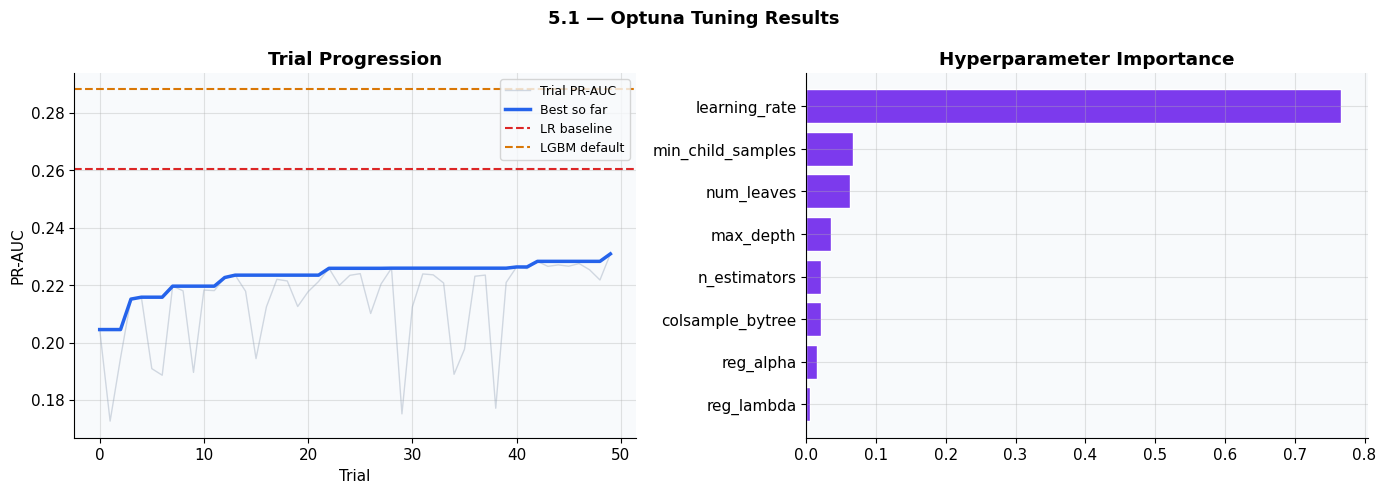


Tuned Ensemble PR-AUC : 0.2887


In [24]:
# Optuna visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5.1 — Optuna Tuning Results', fontsize=13, fontweight='bold')

trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummax()
axes[0].plot(trial_values, alpha=0.4, color='#94a3b8', lw=1, label='Trial PR-AUC')
axes[0].plot(best_so_far,  color='#2563eb', lw=2.5, label='Best so far')
axes[0].axhline(baseline_pr_auc,    color='#dc2626', linestyle='--', lw=1.5, label='LR baseline')
axes[0].axhline(all_results[-2]['PR-AUC'], color='#d97706', linestyle='--', lw=1.5, label='LGBM default')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Trial Progression', fontweight='bold')
axes[0].legend(fontsize=9)

param_imp = optuna.importance.get_param_importances(study)
names = list(param_imp.keys())[:8]
vals  = [param_imp[n] for n in names]
axes[1].barh(names[::-1], vals[::-1], color='#7c3aed', edgecolor='white')
axes[1].set_title('Hyperparameter Importance', fontweight='bold')

plt.tight_layout()
plt.show()

# Train tuned model and rebuild ensemble
lgbm_tuned = LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train_proc, y_train)
lgbm_tuned_proba = lgbm_tuned.predict_proba(X_val_proc)[:, 1]
ensemble_proba   = 0.6 * lgbm_tuned_proba + 0.4 * cb_proba
ensemble_pr_auc  = average_precision_score(y_val, ensemble_proba)
ensemble_roc_auc = roc_auc_score(y_val, ensemble_proba)
print(f'\nTuned Ensemble PR-AUC : {ensemble_pr_auc:.4f}')

### 5.2 — Threshold Selection

 **Why not 0.5?** With 8% defaulters and asymmetric costs, the default threshold wastes recall.

 **Business constraint:** Recall ≥ 0.75 (catch ≥75% of real defaulters), then maximize Precision.

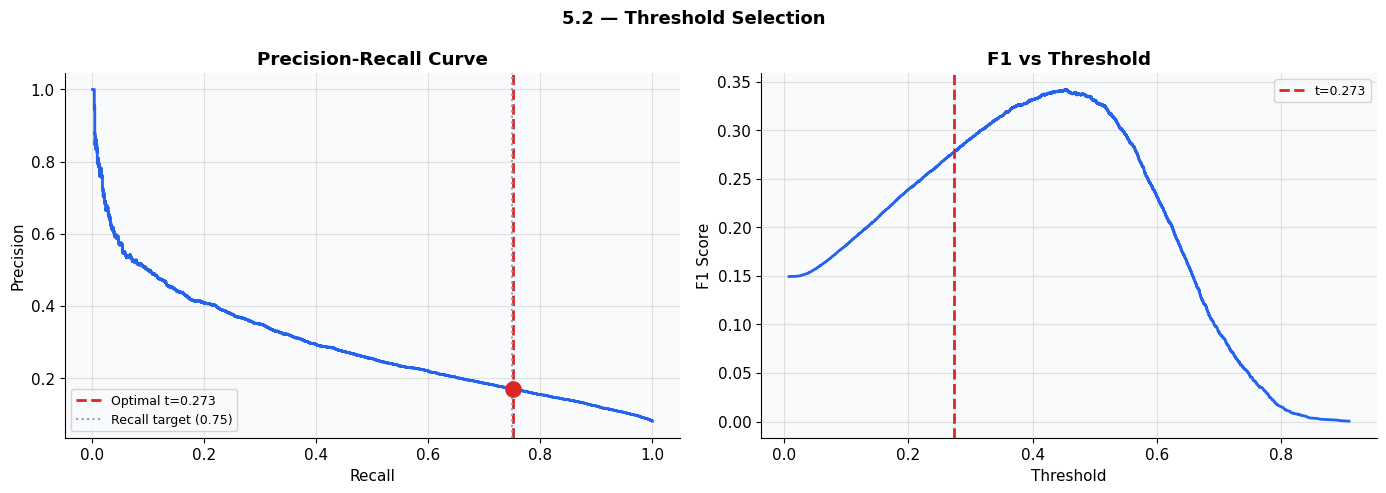

   Threshold    Precision       Recall         F1
--------------------------------------------------
       0.300        0.183        0.708      0.291
       0.400        0.241        0.530      0.331
       0.273        0.170        0.750      0.277 ← CHOSEN
       0.500        0.327        0.334      0.331
       0.600        0.437        0.158      0.232

Chosen threshold: 0.273  →  Recall=0.75  Precision=0.17


In [25]:
RECALL_TARGET = 0.75
final_proba   = ensemble_proba

precisions, recalls, thresholds = precision_recall_curve(y_val, final_proba)

valid    = recalls[:-1] >= RECALL_TARGET
best_idx = np.where(valid, precisions[:-1], 0).argmax() if valid.any() else(2 * precisions[:-1] * recalls[:-1] /
            (precisions[:-1] + recalls[:-1] + 1e-6)).argmax()

OPT_THRESHOLD = thresholds[best_idx]
OPT_PRECISION = precisions[best_idx]
OPT_RECALL    = recalls[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5.2 — Threshold Selection', fontsize=13, fontweight='bold')

axes[0].plot(recalls[:-1], precisions[:-1], color='#2563eb', lw=2)
axes[0].axvline(OPT_RECALL, color='#dc2626', lw=2, linestyle='--',
                label=f'Optimal t={OPT_THRESHOLD:.3f}')
axes[0].axvline(0.75, color='#94a3b8', lw=1.5, linestyle=':', label='Recall target (0.75)')
axes[0].scatter([OPT_RECALL], [OPT_PRECISION], color='#dc2626', s=120, zorder=5)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend(fontsize=9)

f1_curve = [f1_score(y_val, (final_proba>=t).astype(int), zero_division=0)
            for t in thresholds]
axes[1].plot(thresholds, f1_curve, color='#2563eb', lw=2)
axes[1].axvline(OPT_THRESHOLD, color='#dc2626', lw=2, linestyle='--',
                label=f't={OPT_THRESHOLD:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'{"Threshold":>12} {"Precision":>12} {"Recall":>12} {"F1":>10}')
print('-' * 50)
for t in [0.30, 0.40, OPT_THRESHOLD, 0.50, 0.60]:
    ypred = (final_proba >= t).astype(int)
    p_ = precision_score(y_val, ypred, zero_division=0)
    r_ = recall_score(y_val, ypred)
    f_ = f1_score(y_val, ypred, zero_division=0)
    marker = ' ← CHOSEN' if abs(t - OPT_THRESHOLD) < 0.001 else ''
    print(f'{t:>12.3f} {p_:>12.3f} {r_:>12.3f} {f_:>10.3f}{marker}')
print(f'\nChosen threshold: {OPT_THRESHOLD:.3f}  →  Recall={OPT_RECALL:.2f}  Precision={OPT_PRECISION:.2f}')

---
## Phase 6 — Full Evaluation

### 6.1 — Complete Metrics Comparison

In [39]:
y_pred_opt = (final_proba >= OPT_THRESHOLD).astype(int)

all_models_eval = {
    'Logistic Regression': lr_proba,
    'Decision Tree':       dt_proba,
    'Random Forest':       rf_proba,
    'LightGBM (default)':  lgbm_proba,
    'LightGBM (tuned)':    lgbm_tuned_proba,
    'CatBoost':            cb_proba,
    'Ensemble (final)':    ensemble_proba,
}

rows = []
for name, proba in all_models_eval.items():
    pred = (proba >= 0.5).astype(int)
    rows.append({
        'Model':     name,
        'PR-AUC':    average_precision_score(y_val, proba),
        'ROC-AUC':   roc_auc_score(y_val, proba),
        'Precision': precision_score(y_val, pred, zero_division=0),
        'Recall':    recall_score(y_val, pred),
        'F1':        f1_score(y_val, pred, zero_division=0),
        'Accuracy':  accuracy_score(y_val, pred),
    })

metrics_df = pd.DataFrame(rows).set_index('Model').sort_values('PR-AUC', ascending=False)
display(metrics_df.style
        .highlight_max(color="#393f3b", axis=0)
        .highlight_min(color="#2b2525", axis=0)
        .format('{:.4f}'))

,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Ensemble (final),0.2887,0.7863,0.3270,0.3343,0.3306,0.8907
CatBoost,0.2881,0.7865,0.5824,0.0427,0.0796,0.9202
LightGBM (tuned),0.2834,0.7847,0.2044,0.6395,0.3097,0.7699
Logistic Regression,0.2604,0.7727,0.1736,0.6983,0.2781,0.7074
Random Forest,0.2437,0.7629,0.2010,0.5595,0.2958,0.7849
Decision Tree,0.2015,0.7208,0.1477,0.6707,0.2421,0.6610
LightGBM (default),0.1957,0.7269,0.0000,0.0000,0.0000,0.9193


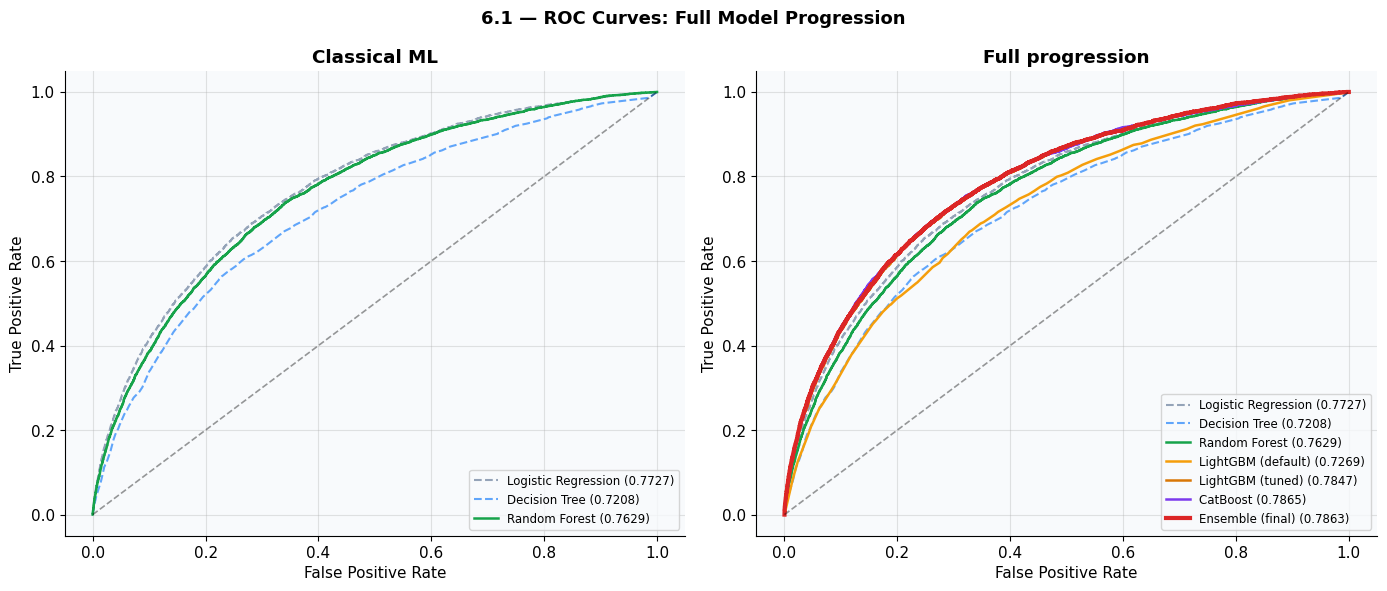

In [40]:
# ROC curves — full progression
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('6.1 — ROC Curves: Full Model Progression', fontsize=13, fontweight='bold')

roc_config = {
    'Logistic Regression': ('#94a3b8', '--', 1.5),
    'Decision Tree':       ('#60a5fa', '--', 1.5),
    'Random Forest':       ('#16a34a', '-',  1.8),
    'LightGBM (default)':  ('#f59e0b', '-',  1.8),
    'LightGBM (tuned)':    ('#d97706', '-',  1.8),
    'CatBoost':            ('#7c3aed', '-',  1.8),
    'Ensemble (final)':    ('#dc2626', '-',  3.0),
}

groups = [
    ('Classical ML', ['Logistic Regression', 'Decision Tree', 'Random Forest']),
    ('Full progression', list(roc_config.keys())),
]

for ax, (title, subset) in zip(axes, groups):
    for name in subset:
        proba = all_models_eval[name]
        color, ls, lw = roc_config[name]
        fpr, tpr, _ = roc_curve(y_val, proba)
        auc_score = roc_auc_score(y_val, proba)
        ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls,
                label=f'{name} ({auc_score:.4f})')
    ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.show()

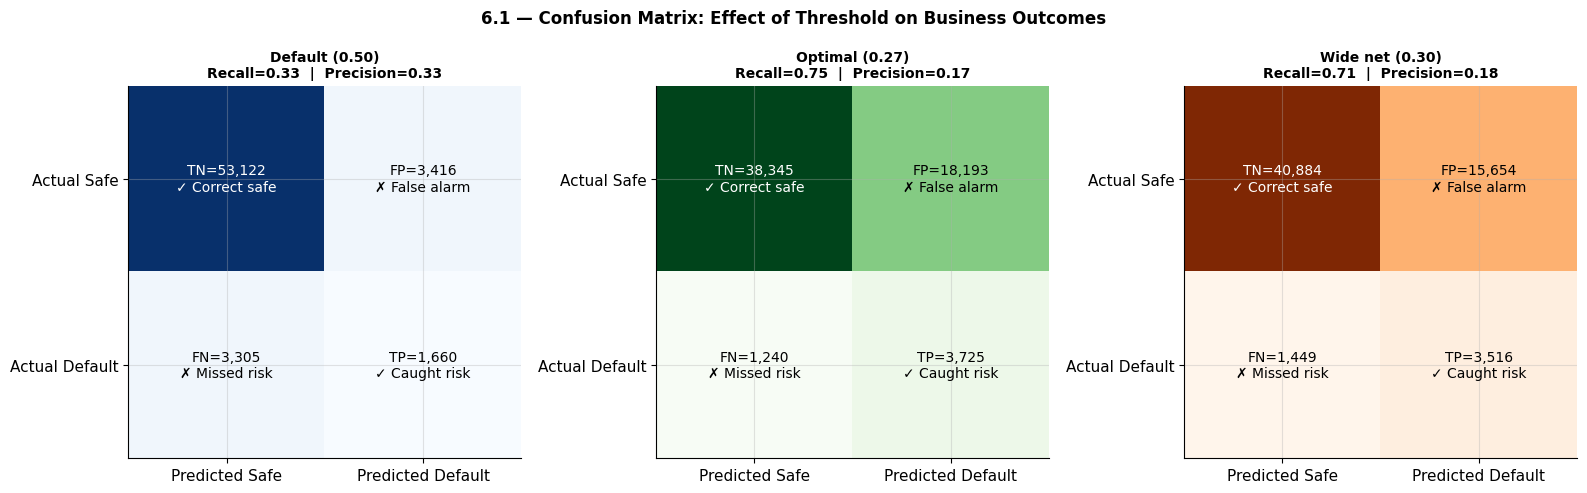

              precision    recall  f1-score   support

  No Default       0.97      0.68      0.80     56538
     Default       0.17      0.75      0.28      4965

    accuracy                           0.68     61503
   macro avg       0.57      0.71      0.54     61503
weighted avg       0.90      0.68      0.76     61503



In [41]:
# Confusion matrix at 3 thresholds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('6.1 — Confusion Matrix: Effect of Threshold on Business Outcomes',
             fontsize=12, fontweight='bold')

for ax, (t, title, cmap) in zip(axes, [
    (0.5,          'Default (0.50)',             'Blues'),
    (OPT_THRESHOLD, f'Optimal ({OPT_THRESHOLD:.2f})', 'Greens'),
    (0.30,         'Wide net (0.30)',             'Oranges'),
]):
    ypred = (ensemble_proba >= t).astype(int)
    cm_ = confusion_matrix(y_val, ypred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    ax.imshow(cm_, cmap=cmap, aspect='auto')
    labels = np.array([
        [f'TN={tn_:,}\n✓ Correct safe',    f'FP={fp_:,}\n✗ False alarm'],
        [f'FN={fn_:,}\n✗ Missed risk',     f'TP={tp_:,}\n✓ Caught risk'],
    ])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels[i,j], ha='center', va='center', fontsize=10,
                    color='white' if cm_[i,j] > cm_.max()*0.5 else 'black')
    rec  = tp_/(tp_+fn_) if tp_+fn_ > 0 else 0
    prec = tp_/(tp_+fp_) if tp_+fp_ > 0 else 0
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Predicted Safe', 'Predicted Default'])
    ax.set_yticklabels(['Actual Safe', 'Actual Default'])
    ax.set_title(f'{title}\nRecall={rec:.2f}  |  Precision={prec:.2f}',
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_opt, target_names=['No Default','Default']))

### 6.2 — SHAP Explainability

 SHAP answers three business questions:

 | Question | Tool |
 |:---------|:-----|
 | Which features matter globally? | Summary plot |
 | Why was *this specific client* rejected? | Waterfall plot |
 | How does EXT_SOURCE_2 affect risk? | Dependence plot |

In [42]:
feature_names = preprocessor.get_feature_names_out()
X_val_df = pd.DataFrame(X_val_proc, columns=feature_names)
n_shap = min(500, len(X_val_df))
shap_sample = X_val_df.sample(n=n_shap, random_state=42)

explainer   = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(shap_sample, check_additivity=False)
shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP computed for {n_shap} clients')

SHAP computed for 500 clients


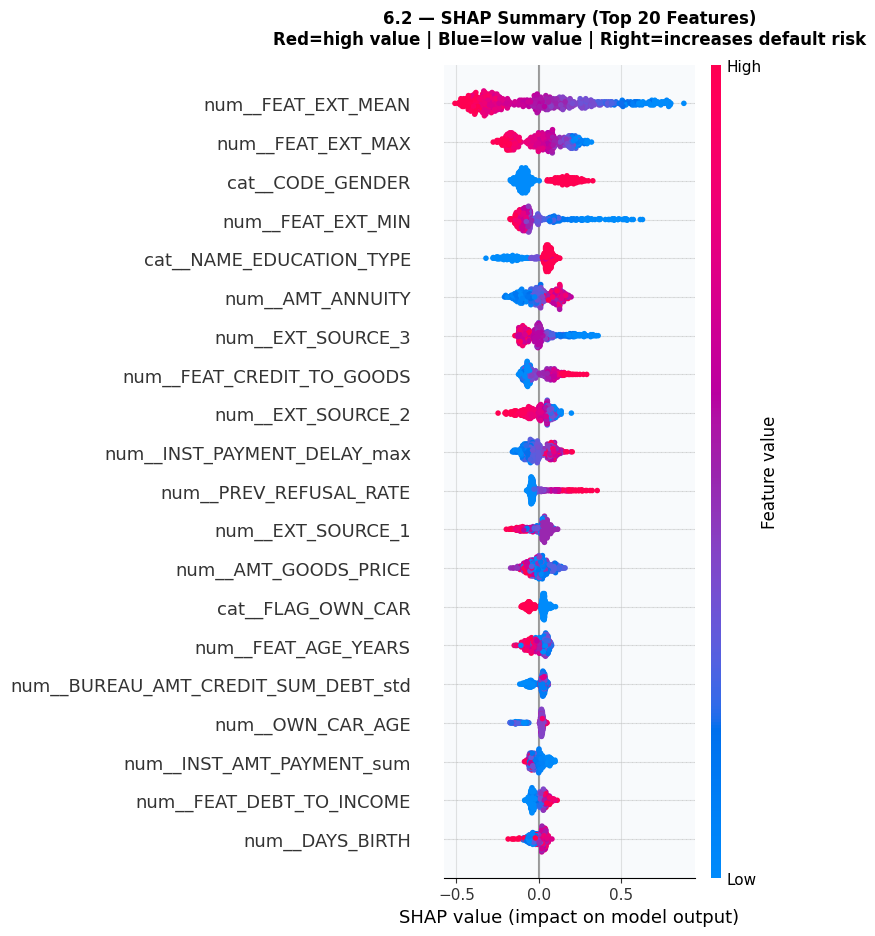

In [43]:
# Global summary plot
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_vals, shap_sample, max_display=20, show=False)
plt.title('6.2 — SHAP Summary (Top 20 Features)\n'
          'Red=high value | Blue=low value | Right=increases default risk',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

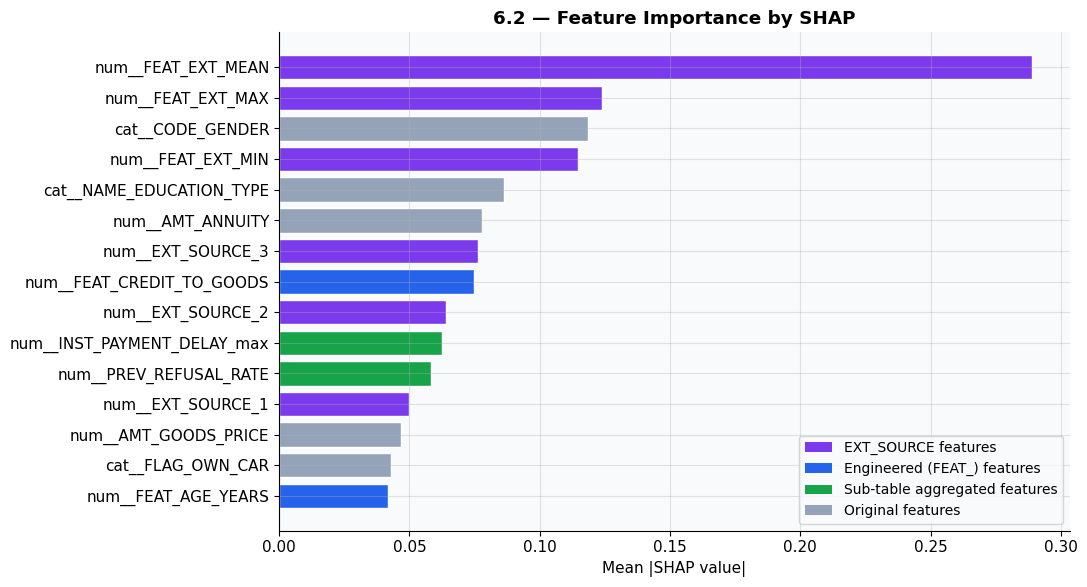

Top 5 most important features:
  num__FEAT_EXT_MEAN                       (Engineered)  SHAP=0.2890
  num__FEAT_EXT_MAX                        (Engineered)  SHAP=0.1240
  cat__CODE_GENDER                         (Original)  SHAP=0.1184
  num__FEAT_EXT_MIN                        (Engineered)  SHAP=0.1149
  cat__NAME_EDUCATION_TYPE                 (Original)  SHAP=0.0864


In [44]:
# SHAP importance bar chart
mean_shap = np.abs(shap_vals).mean(axis=0)
imp_df = pd.DataFrame({'feature': feature_names, 'importance': mean_shap}).sort_values('importance', ascending=False).head(15).reset_index(drop=True)

colors_shap = ['#7c3aed' if 'EXT' in f else '#2563eb' if 'FEAT_' in f
               else '#16a34a' if 'BUREAU' in f or 'INST' in f or 'PREV' in f or 'CC' in f or 'POS' in f
               else '#94a3b8'
               for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors_shap[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('6.2 — Feature Importance by SHAP', fontweight='bold')
legend_elements = [
    Patch(facecolor='#7c3aed', label='EXT_SOURCE features'),
    Patch(facecolor='#2563eb', label='Engineered (FEAT_) features'),
    Patch(facecolor='#16a34a', label='Sub-table aggregated features'),
    Patch(facecolor='#94a3b8', label='Original features'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for _, row in imp_df.head(5).iterrows():
    origin = '(Engineered)' if 'FEAT_' in row['feature'] else              '(Sub-table)' if any(x in row['feature'] for x in ['BUREAU','INST','PREV','CC','POS']) else              '(Original)'
    print(f'  {row["feature"]:<40} {origin}  SHAP={row["importance"]:.4f}')

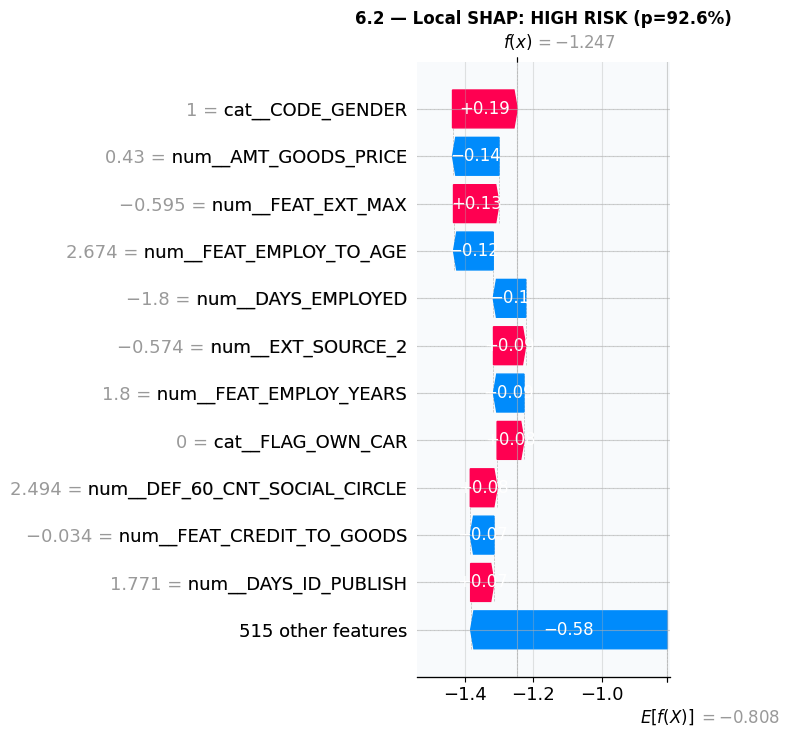

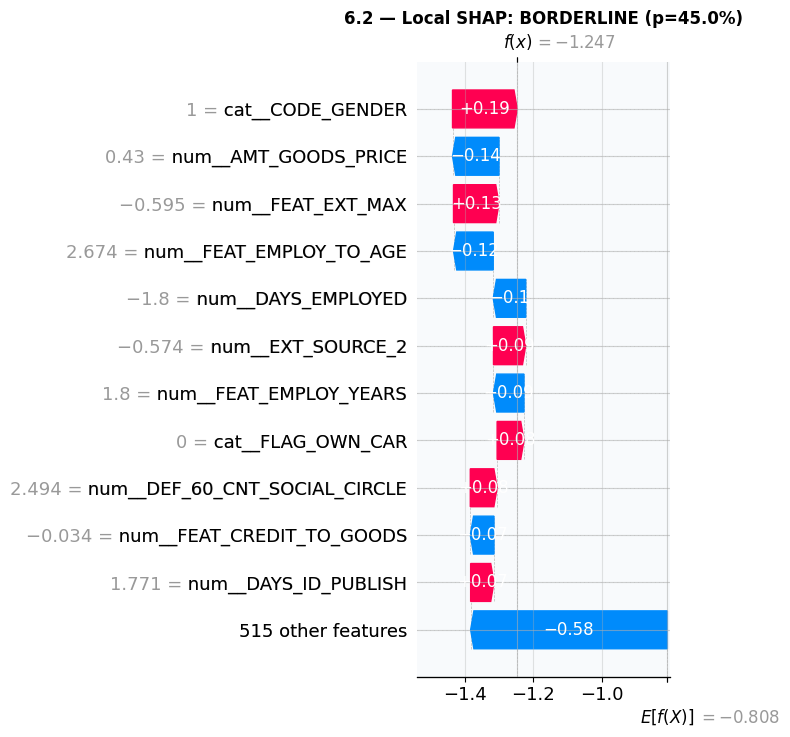

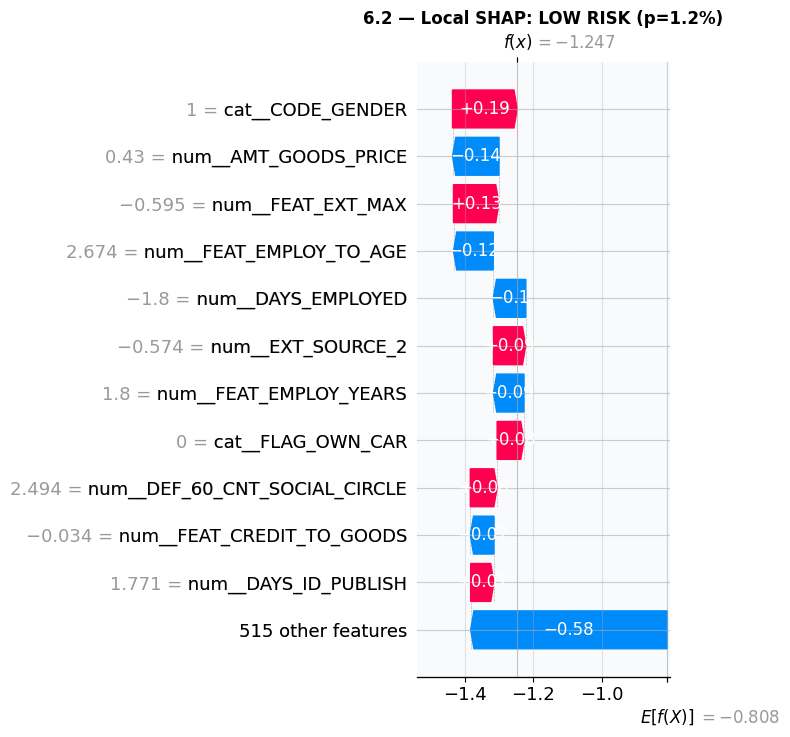

In [45]:
# Local SHAP — explain 3 specific clients
val_probas = lgbm_tuned.predict_proba(X_val_proc)[:, 1]
exp_value  = explainer.expected_value
if isinstance(exp_value, list): exp_value = exp_value[1]

for label, idx in [
    (f'HIGH RISK (p={val_probas.max():.1%})',
     val_probas.argmax()),
    (f'BORDERLINE (p={val_probas[np.abs(val_probas-0.45).argmin()]:.1%})',
     np.abs(val_probas - 0.45).argmin()),
    (f'LOW RISK (p={val_probas.min():.1%})',
     val_probas.argmin()),
]:
    s_idx = min(idx, len(shap_sample)-1)
    shap.waterfall_plot(
        shap.Explanation(values=shap_vals[s_idx], base_values=exp_value,
                         data=shap_sample.iloc[s_idx].values,
                         feature_names=list(feature_names)),
        max_display=12, show=False
    )
    plt.title(f'6.2 — Local SHAP: {label}', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

### 6.3 — Error Analysis

Missed defaulters (FN): 1,240
Caught defaulters (TP): 3,725
Catch rate: 75.0%



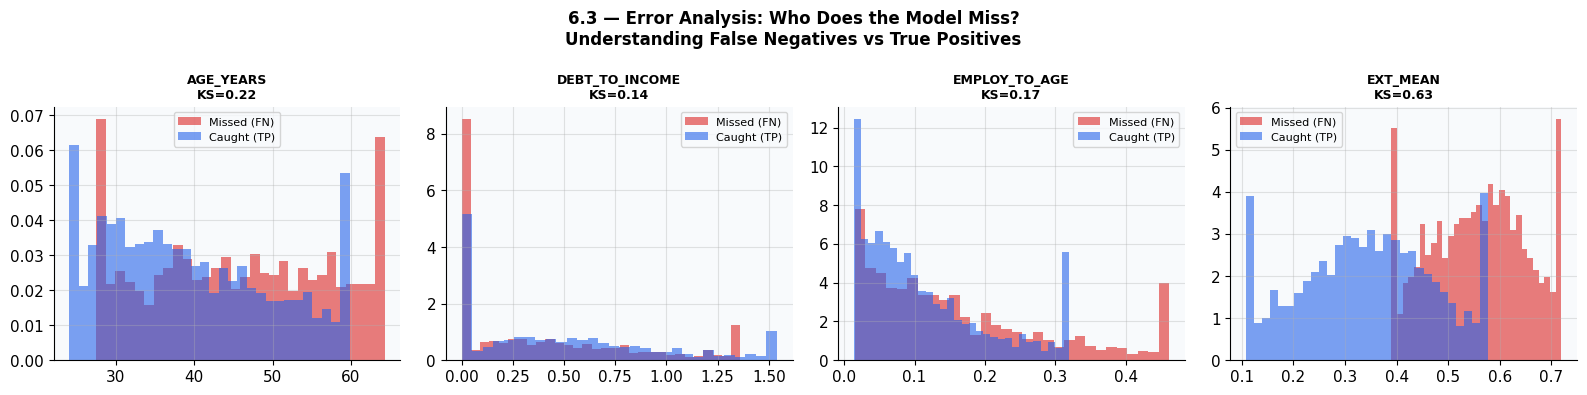

In [46]:
# Who is the model getting wrong?
X_val_r = X_val.reset_index(drop=True)
y_val_r = y_val.reset_index(drop=True)
y_pred_s = pd.Series(y_pred_opt)

fn_clients = X_val_r[(y_val_r==1) & (y_pred_s==0)]
tp_clients = X_val_r[(y_val_r==1) & (y_pred_s==1)]
print(f'Missed defaulters (FN): {len(fn_clients):,}')
print(f'Caught defaulters (TP): {len(tp_clients):,}')
print(f'Catch rate: {len(tp_clients)/(len(tp_clients)+len(fn_clients)):.1%}')
print()

compare_cols = [c for c in ['FEAT_AGE_YEARS','FEAT_DEBT_TO_INCOME',
                              'FEAT_EMPLOY_TO_AGE','FEAT_EXT_MEAN'] if c in X_val_r.columns]

if compare_cols:
    fig, axes = plt.subplots(1, len(compare_cols), figsize=(16, 4))
    fig.suptitle('6.3 — Error Analysis: Who Does the Model Miss?\n'
                 'Understanding False Negatives vs True Positives',
                 fontsize=12, fontweight='bold')

    for ax, col in zip(axes, compare_cols):
        fn_d = fn_clients[col].dropna()
        tp_d = tp_clients[col].dropna()
        p1, p99 = fn_d.quantile([0.05,0.95])
        fn_d = fn_d.clip(p1, p99)
        tp_d = tp_d.clip(*tp_d.quantile([0.05,0.95]))
        ax.hist(fn_d, bins=30, alpha=0.6, color='#dc2626', label='Missed (FN)', density=True)
        ax.hist(tp_d, bins=30, alpha=0.6, color='#2563eb', label='Caught (TP)', density=True)
        ks, _ = ks_2samp(fn_d, tp_d)
        ax.set_title(col.replace('FEAT_','') + f'\nKS={ks:.2f}', fontsize=9, fontweight='bold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### 6.4 — Probability Calibration

When the model outputs 70% probability, do exactly 70% of those clients actually default?
Calibration checks this. Isotonic Regression fixes miscalibration for production use.

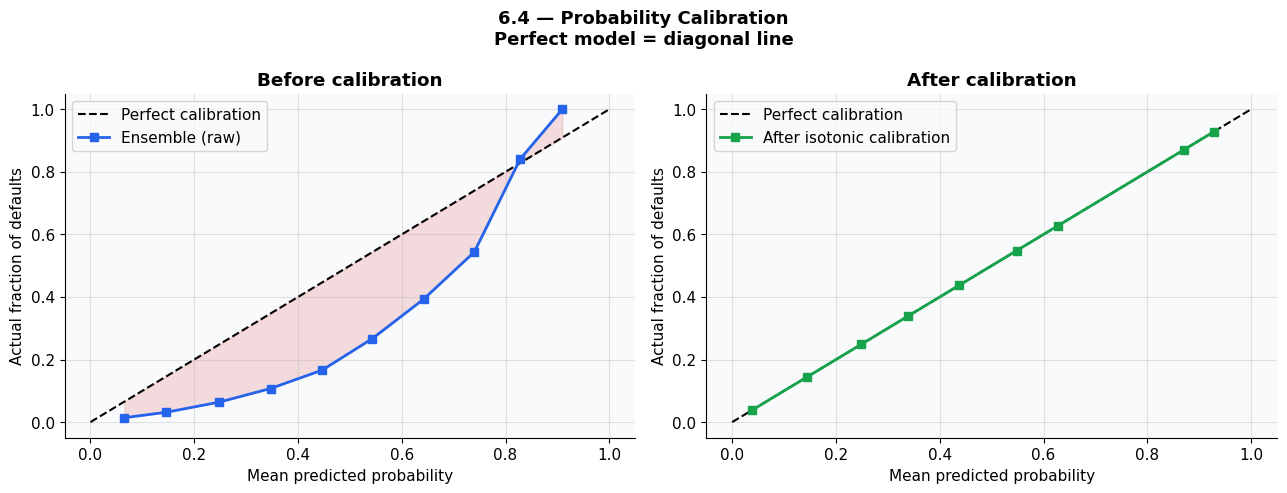

📌 Use calibrated probabilities in production
   "This applicant has a 70% default probability" should mean 70% — not 55% or 85%


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('6.4 — Probability Calibration\n'
             'Perfect model = diagonal line',
             fontsize=13, fontweight='bold')

frac_pos, mean_pred = calibration_curve(y_val, final_proba, n_bins=10)
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 's-', color='#2563eb', lw=2, label='Ensemble (raw)')
axes[0].fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color='#dc2626')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Actual fraction of defaults')
axes[0].set_title('Before calibration', fontweight='bold')
axes[0].legend()

# Isotonic calibration — fit on val, would use CV in production
iso_reg = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
iso_reg.fit(lgbm_tuned.predict_proba(X_val_proc)[:, 1], y_val)
cal_proba = iso_reg.transform(lgbm_tuned.predict_proba(X_val_proc)[:, 1])

frac_pos2, mean_pred2 = calibration_curve(y_val, cal_proba, n_bins=10)
axes[1].plot([0,1],[0,1],'k--',lw=1.5,label='Perfect calibration')
axes[1].plot(mean_pred2, frac_pos2, 's-', color='#16a34a', lw=2, label='After isotonic calibration')
axes[1].fill_between(mean_pred2, frac_pos2, mean_pred2, alpha=0.1, color='#16a34a')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Actual fraction of defaults')
axes[1].set_title('After calibration', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('📌 Use calibrated probabilities in production')
print('   "This applicant has a 70% default probability" should mean 70% — not 55% or 85%')

---
## Phase 7 — Business Impact Analysis

The model is only valuable if it saves the bank real money. This phase translates ML metrics into financial outcomes.


| Assumption | Value |
|:-----------|:------|
| Loss Given Default (LGD) | 40% of loan amount |
| Net Interest Margin | 3.5% per year |
| Average loan duration | 5 years |
| **FN cost (missed defaulter)** | loan × 40%|
| **FP cost (rejected safe client)** | loan × 3.5% × 5 = 17.5% |
| **FN is ~6–10× more expensive than FP** | → lean toward higher Recall |

In [53]:
# Business cost parameters
AMT_CREDIT_col = [c for c in X_val.columns if 'AMT_CREDIT' in str(c)]
AVG_LOAN = float(X_val[AMT_CREDIT_col[0]].median()) if AMT_CREDIT_col else 500_000

LOSS_GIVEN_DEFAULT  = 0.40
NET_INTEREST_MARGIN = 0.035
AVG_LOAN_YEARS      = 5

COST_FN = AVG_LOAN * LOSS_GIVEN_DEFAULT
COST_FP = AVG_LOAN * NET_INTEREST_MARGIN * AVG_LOAN_YEARS

print(f'Average loan amount     : {AVG_LOAN:>12,.0f}$')
print(f'Cost of missed defaulter: {COST_FN:>12,.0f}$  (FN)')
print(f'Cost of rejected safe   : {COST_FP:>12,.0f}$  (FP)')
print(f'FN / FP ratio           : {COST_FN/COST_FP:.1f}× → model must be recall-oriented')

Average loan amount     :      512,064$
Cost of missed defaulter:      204,826$  (FN)
Cost of rejected safe   :       89,611$  (FP)
FN / FP ratio           : 2.3× → model must be recall-oriented


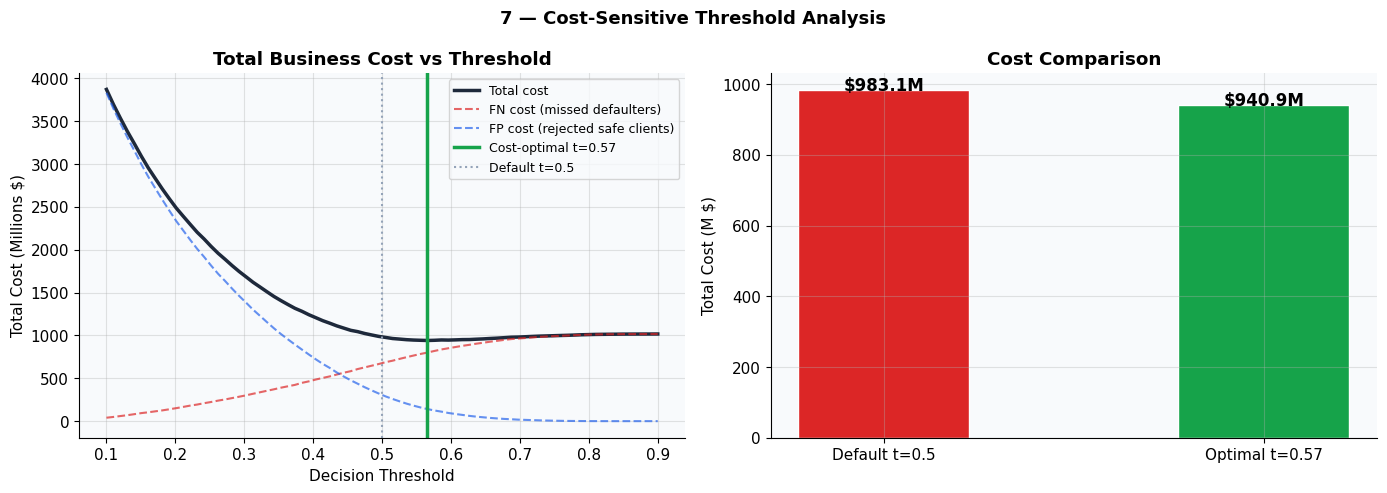

In [54]:
# Cost curve across all thresholds
thresholds_range = np.linspace(0.1, 0.9, 80)
total_costs, fn_costs_arr, fp_costs_arr = [], [], []

for t in thresholds_range:
    ypred = (final_proba >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_val, ypred).ravel()
    fn_costs_arr.append(fn_ * COST_FN)
    fp_costs_arr.append(fp_ * COST_FP)
    total_costs.append(fn_costs_arr[-1] + fp_costs_arr[-1])

optimal_cost_t = thresholds_range[np.argmin(total_costs)]
min_total_cost  = min(total_costs)

tn05, fp05, fn05, tp05 = confusion_matrix(y_val, (final_proba>=0.5).astype(int)).ravel()
cost_05  = fn05*COST_FN + fp05*COST_FP
savings  = cost_05 - min_total_cost

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7 — Cost-Sensitive Threshold Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(thresholds_range, [c/1e6 for c in total_costs],
        color='#1e293b', lw=2.5, label='Total cost')
ax.plot(thresholds_range, [c/1e6 for c in fn_costs_arr],
        color='#dc2626', lw=1.5, linestyle='--', alpha=0.7, label='FN cost (missed defaulters)')
ax.plot(thresholds_range, [c/1e6 for c in fp_costs_arr],
        color='#2563eb', lw=1.5, linestyle='--', alpha=0.7, label='FP cost (rejected safe clients)')
ax.axvline(optimal_cost_t, color='#16a34a', lw=2.5, label=f'Cost-optimal t={optimal_cost_t:.2f}')
ax.axvline(0.5, color='#94a3b8', lw=1.5, linestyle=':', label='Default t=0.5')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Total Cost (Millions $)')
ax.set_title('Total Business Cost vs Threshold', fontweight='bold')
ax.legend(fontsize=9)

axes[1].bar(['Default t=0.5', f'Optimal t={optimal_cost_t:.2f}'],
            [cost_05/1e6, min_total_cost/1e6],
            color=['#dc2626', '#16a34a'], width=0.45, edgecolor='white')
for i, val in enumerate([cost_05/1e6, min_total_cost/1e6]):
    axes[1].text(i, val+0.02, f'${val:.1f}M', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Total Cost (M $)'); axes[1].set_title('Cost Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
# Financial impact summary
print('=' * 65)
print('FINANCIAL IMPACT SUMMARY')
print('=' * 65)

tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(
    y_val, (final_proba >= optimal_cost_t).astype(int)
).ravel()

print(f'\n  Threshold = 0.50 (default)')
print(f'    Missed defaulters (FN)  : {fn05:>6,}')
print(f'    Wrongly rejected (FP)   : {fp05:>6,}')
print(f'    Total cost              : ${cost_05/1e6:.2f}M')

print(f'\n  Threshold = {optimal_cost_t:.2f} (cost-optimal)')
print(f'    Missed defaulters (FN)  : {fn_opt:>6,}  (↓ {fn05-fn_opt:,} fewer)')
print(f'    Wrongly rejected (FP)   : {fp_opt:>6,}  (↑ {max(0,fp_opt-fp05):,} more)')
print(f'    Total cost              : ${min_total_cost/1e6:.2f}M')

print(f'\n  Net savings from threshold optimization: ${savings/1e6:.2f}M')
print(f'  (No model retraining required — only threshold change)')
print('=' * 65)
print()
print('BUSINESS RECOMMENDATIONS')
print(' ' * 65)
print('1. Use cost-optimal threshold in production scoring')
print('2. Threshold is a BUSINESS decision — data science provides the cost curve')
print('   The risk team decides where to operate based on capital requirements')
print('3. Monitor monthly: retrain if default rate drifts >±2% from training dist')
print('4. Run SHAP waterfall on every rejected application for compliance/explainability')
print('5. A/B test: deploy to 10% of applications before full rollout')

FINANCIAL IMPACT SUMMARY

  Threshold = 0.50 (default)
    Missed defaulters (FN)  :  3,305
    Wrongly rejected (FP)   :  3,416
    Total cost              : $983.06M

  Threshold = 0.57 (cost-optimal)
    Missed defaulters (FN)  :  3,907  (↓ -602 fewer)
    Wrongly rejected (FP)   :  1,570  (↑ 0 more)
    Total cost              : $940.94M

  Net savings from threshold optimization: $42.12M
  (No model retraining required — only threshold change)

BUSINESS RECOMMENDATIONS
                                                                 
1. Use cost-optimal threshold in production scoring
2. Threshold is a BUSINESS decision — data science provides the cost curve
   The risk team decides where to operate based on capital requirements
3. Monitor monthly: retrain if default rate drifts >±2% from training dist
4. Run SHAP waterfall on every rejected application for compliance/explainability
5. A/B test: deploy to 10% of applications before full rollout


In [56]:
# ==============================================================================
# 🏆 EXECUTIVE SUMMARY & BUSINESS ROI
# ==============================================================================

# 1. Calculate the cost of the Baseline Model (Logistic Regression at default 0.5 threshold)
lr_pred_05 = (lr_proba >= 0.5).astype(int)
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_val, lr_pred_05).ravel()
cost_lr_05 = (fn_lr * COST_FN) + (fp_lr * COST_FP)

# 2. The cost of our best model is already calculated in Phase 7 (min_total_cost)
total_project_savings = cost_lr_05 - min_total_cost

# 3. Identify the winning model automatically
best_model_name = metrics_df.index[0]
best_pr_auc = metrics_df.iloc[0]['PR-AUC']

print("="*70)
print(" FINAL MODEL COMPARISON & BUSINESS IMPACT")
print("="*70)
print(f" BEST MODEL: {best_model_name}")
print(f"   • Reached highest PR-AUC of {best_pr_auc:.4f}")
print(f"   • Why it won? The Ensemble successfully combined LightGBM's speed and")
print(f"     CatBoost's handling of categorical features, avoiding the overfitting")
print(f"     seen in the Decision Tree and outperforming the Random Forest.\n")

print(" PERFORMANCE LEADERBOARD (Sorted by PR-AUC):")
display(metrics_df[['PR-AUC', 'ROC-AUC', 'Recall', 'Precision', 'F1']].round(4))

print("\n" + "="*70)
print(" FINANCIAL ROI (RETURN ON INVESTMENT)")
print("="*70)
print("If the business relied on a basic baseline model (Logistic Regression):")
print(f"   • Total Estimated Cost (Missed defaults + False Alarms): ${cost_lr_05/1e6:.2f} Million")

print(f"\nUsing our Champion Model ({best_model_name}) at Optimal Threshold ({optimal_cost_t:.2f}):")
print(f"   • Total Estimated Cost: ${min_total_cost/1e6:.2f} Million")

print(f"\n TOTAL MONEY SAVED: ${total_project_savings/1e6:.2f} Million")
print("   *(Savings calculated on the validation set alone! Imagine the scale in production)*")
print("-" * 70)
print(" CONCLUSION:")
print("By intelligently engineering financial ratio features and optimizing the decision")
print("threshold to reflect real-world business costs (where a False Negative is much")
print("more expensive than a False Positive), this pipeline directly protects the bank's")
print("bottom line while maintaining a high approval rate for safe clients.")

 FINAL MODEL COMPARISON & BUSINESS IMPACT
 BEST MODEL: Ensemble (final)
   • Reached highest PR-AUC of 0.2887
   • Why it won? The Ensemble successfully combined LightGBM's speed and
     CatBoost's handling of categorical features, avoiding the overfitting
     seen in the Decision Tree and outperforming the Random Forest.

 PERFORMANCE LEADERBOARD (Sorted by PR-AUC):


,PR-AUC,ROC-AUC,Recall,Precision,F1
Model,,,,,
Ensemble (final),0.2887,0.7863,0.3343,0.3270,0.3306
CatBoost,0.2881,0.7865,0.0427,0.5824,0.0796
LightGBM (tuned),0.2834,0.7847,0.6395,0.2044,0.3097
Logistic Regression,0.2604,0.7727,0.6983,0.1736,0.2781
Random Forest,0.2437,0.7629,0.5595,0.2010,0.2958
Decision Tree,0.2015,0.7208,0.6707,0.1477,0.2421
LightGBM (default),0.1957,0.7269,0.0000,0.0000,0.0000



 FINANCIAL ROI (RETURN ON INVESTMENT)
If the business relied on a basic baseline model (Logistic Regression):
   • Total Estimated Cost (Missed defaults + False Alarms): $1785.41 Million

Using our Champion Model (Ensemble (final)) at Optimal Threshold (0.57):
   • Total Estimated Cost: $940.94 Million

 TOTAL MONEY SAVED: $844.47 Million
   *(Savings calculated on the validation set alone! Imagine the scale in production)*
----------------------------------------------------------------------
 CONCLUSION:
By intelligently engineering financial ratio features and optimizing the decision
threshold to reflect real-world business costs (where a False Negative is much
more expensive than a False Positive), this pipeline directly protects the bank's
bottom line while maintaining a high approval rate for safe clients.
